# Point vs. Volumetric Targets

This exercise explores the effect of applying a volumetric interpretation to a point-target sample volume. 
### Approximating Point Scattering as Volumetric
We know the single-scattering point-target lidar equation for multiple particles is
$$P_r(R;\textbf{x}) = C(R)\sum_{i=1}^{N} I(x_i,y_i,z_i)\frac{d\sigma_b(s_i)}{d\Omega}$$
where $C(R) \approx AR^{-2} T^2(R)O(R)\eta$ for small enough $\Delta R$. The sum term can be approximated by the expectation value, based on the law of large numbers and i.i.d. sampling:
$$\frac{1}{N}\sum_{i=1}^{N} I(x_i,y_i,z_i)\frac{d\sigma_b(s_i)}{d\Omega} \approx E\left[I(x,y,z)\frac{d\sigma_b(s)}{d\Omega}\right]=\int_{D}I(x,y,z)\frac{d\sigma_b(s)}{d\Omega}p(\textbf{x})d\textbf{x}$$
where $p(\textbf{x})$ is the pdf of the particle parameters (location and size). We know the pdf is $p(\textbf{x})=u(x,y,z)g(s)=V^{-1}g(s)$, where $u$ is a uniform boxcar function over the volume $V$. We can use this to say
$$\sum_{i=1}^{N} I(x_i,y_i,z_i)\frac{d\sigma_b(s_i)}{d\Omega} \approx \frac{N}{V}\int_{V}I(x,y,z)dV\int_{0}^{\infty}\frac{d\sigma_b(s)}{d\Omega}ds$$
Plugging this back into Eq. 1, we get
$$P_r(R;\textbf{x}) \approx C(R)\frac{N}{V}\int_{V}I(x,y,z)dV\int_{0}^{\infty}\frac{d\sigma_b(s)}{d\Omega}ds$$
This simplifies to
$$P_r(R;\textbf{x}) \approx C(R)P_t\Delta R \beta_V$$
where we assume averaging over the entire beam such that $P_t=\int_{A}I(x,y)dA$ is the average transmitted power, $\Delta R$ is the laser pulse length (or distance averaged over if the laser pulse is very short), and $\beta_V=\int_{0}^{\infty}\frac{N}{V}\frac{d\sigma_b(s)}{d\Omega}ds$ is the backscatter volume coefficient.

### Uncertainty Quantification
The uncertainty (or relative expected error) in the summation term (or equivalently the volume integral, since these are commutative) is related to the variance of the summation term divided by its expected value:
$$\frac{\delta\mathcal{P}}{\mathcal{P}}=\frac{\sqrt{Var(\mathcal{P})}}{E[\mathcal{P}]}$$
where $\mathcal{P}=\sum_{i=1}^{N} I(x_i,y_i,z_i)\frac{d\sigma_b(s_i)}{d\Omega}$. For the UQ formulation, I will use the shorthand random variable notation $I(x,y,z)=I$ and $\frac{d\sigma_b(s_i)}{d\Omega}=S$. We know that
$$\mathrm{Var}\left(\sum_{i=1}^{N}I_iS_i\right)=N\mathrm{Var}(IS)$$
We also use the variance multiplication property to expand
$$\mathrm{Var}(IS)=\mathrm{Var}(I)(E[S])^2+\mathrm{Var}(S)(E[I])^2 + \mathrm{Var}(I)\mathrm{Var}(S)$$
Plugging this in, we end up with
$$\frac{\delta\mathcal{P}}{\mathcal{P}}=\frac{1}{\sqrt{N}}\sqrt{\frac{\mathrm{Var}(I)}{(E[I])^2}+\frac{\mathrm{Var}(S)}{(E[S])^2}+\frac{\mathrm{Var}(I)}{(E[I])^2}\frac{\mathrm{Var}(S)}{(E[S])^2}}=\frac{1}{\sqrt{N}}\sqrt{\mathrm{CV}_I^2+\mathrm{CV}_S^2+\mathrm{CV}_I^2\mathrm{CV}_S^2}$$
where $\mathrm{CV}_X=\frac{\sqrt{\mathrm{Var}(X)}}{E[X]}$ is the coefficient of variation. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as sp
from scipy.signal import convolve
import math
from scipy.optimize import brentq

### System Specs
TEEM laser waist: 42 um,
Galilean beam expander: 5x,
Beam expander: 9.33x,
Lambda = 532 nm

Gaussian beam propagation (waist is half width here):
$$w(z)=w_0\sqrt{1+\left(\frac{\lambda z}{\pi w_0^2}\right)^2}$$
and half-angle beam divergence
$$\theta=\frac{\lambda}{\pi w_0}$$

Peak irradiance (1D):
$$I_0(z)=\frac{P_{avg}}{\sqrt{2\pi} w(z)}$$
Peak irradiance (2D):
$$I_0(z)=\frac{P_{avg}}{2\pi w(z)^2}$$

Sample volume:
$$V(z) = A(z)\Delta R \approx \pi w(z)^2 \frac{c\tau}{2}$$

where $\tau$ is the range bin size in seconds. 

In [2]:
w_0 = 42e-6  # [m]
expand = 5 * 9.33  # magnification
lamb = 532e-9  # [m]
z = 2e3  # [m]

w_0 *= expand  # magnify waist

w = w_0 * np.sqrt(1 + (lamb * z / np.pi / (w_0**2))**2)

print('Full-width waist @ {:.0f} km: {:.2f} m'.format(z/1e3, 2*w))

theta = lamb / np.pi / w_0

print('Full angle divergence: {:.2f} urad'.format(2* theta * 1e6))

Full-width waist @ 2 km: 0.35 m
Full angle divergence: 172.86 urad


In [3]:
k = np.arange(1, 10, 1)
N = 10 * k
delta = 1/np.sqrt(N) * 0.14

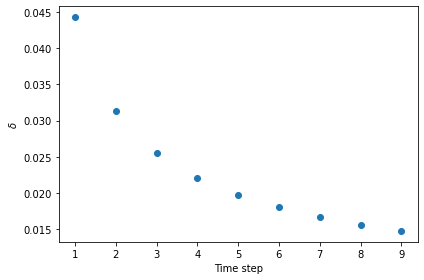

In [4]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(k, delta, 'o')
ax.set_xlabel('Time step')
ax.set_ylabel('$\delta$')
plt.tight_layout()
plt.show()

### Variance of Intensity of a 1D Gaussian Beam
The intensity profile of the beam is gaussian:
$$I(x)=I_0\exp\left(-\frac{x^2}{2\sigma^2}\right)$$
where $I_0$ is the peak irradiance and $\sigma$ is the spatial standard deviation.
Variance is calculated as
$$\mathrm{Var}(I)=E[I^2]-(E[I])^2$$
Assuming the distribution of particles is uniform over some length $2L$ (1D assumption), we can calculate the expectation values as
$$E[I]=\int_{D}I(x)p(x)dx=\frac{1}{2L}\int_{-L}^{L}I_0\exp\left(-\frac{x^2}{2\sigma^2}\right)dx$$
We use the error function identity 
$$\mathrm{erf}(z)=\frac{2}{\sqrt{\pi}}\int_{0}^{z}e^{-t^2}dt$$
to obtain the definite integral
$$E[I]=I_0\sqrt{\frac{\pi}{2}}\frac{\sigma}{L}\mathrm{erf}\left(\frac{L}{\sqrt{2}\sigma}\right)$$
Hint: To rederive this, use the u-substituation method $u=t/a$ and $u^2=(t/a)^2$. We can also find the second moment:
$$E[I^2]=I_0^2\sqrt{\pi}\frac{\sigma}{2L}\mathrm{erf}\left(\frac{L}{\sigma}\right)$$
This results in 
$$\mathrm{Var}(I)=I_0^2\left[\frac{\sqrt{\pi}}{2}\frac{\sigma}{L}\mathrm{erf}\left(\frac{L}{\sigma}\right)-\frac{\pi}{2}\frac{\sigma^2}{L^2}\left[\mathrm{erf}\left(\frac{L}{\sqrt{2}\sigma}\right)\right]^2\right]$$
The coefficient of variation $\mathrm{CV}$ is then
$$\mathrm{CV}_I=\frac{\sqrt{\mathrm{Var}(I)}}{E[I]}$$

In [5]:
# In this exercise, I assume the variance of the backscatter cross section is 0 (single particle size). So CV for cross section is 0.

# Doing this in 1D to start
P_avg = 35e-3  # [W]
I_0 = P_avg / np.sqrt(2 * np.pi) / w  # [W/m]

print('1D Calculations')
print('Peak irradiance: {:.3f} W/m'.format(I_0))

sigma = w / 2  # [m]
L = w  # [m]

Var_I = I_0**2 * (np.sqrt(np.pi) / 2 * sigma / L * sp.erf(L/sigma) - np.pi / 2 * sigma**2 / L**2 * (sp.erf(L / np.sqrt(2) / sigma))**2)  # [W^2 / m^2]
mu_I = I_0 * np.sqrt(np.pi/2) * sigma / L * sp.erf(L / np.sqrt(2) / sigma)  # [W/m]
# print(np.sqrt(Var_I))
print('Expected irradiance: {:.3f} W/m'.format(mu_I))

print('Coefficient of variation: {:.3f}'.format(np.sqrt(Var_I)/mu_I))

1D Calculations
Peak irradiance: 0.081 W/m
Expected irradiance: 0.048 W/m
Coefficient of variation: 0.482


### Extending to 2D

Following the exercise from above, we can solve the integrals
$$E[I]=\int_{A}I(x,y)p(x,y)dA=\frac{1}{A}\int_{0}^{R}\int_{0}^{2\pi}I(r)rdrd\theta$$
where $r^2=x^2+y^2$. Using area $A=\pi R^2$, we can solve
$$E[I]=2I_0\left(\frac{\sigma}{R}\right)^2\left[1-\exp\left(-\frac{R^2}{2\sigma^2}\right)\right]$$
and the second moment
$$E[I^2]=I_0^2\left(\frac{\sigma}{R}\right)^2\left[1-\exp\left(-\frac{R^2}{\sigma^2}\right)\right]$$

In [6]:
# Now extend to 2D

P_avg = 35e-3  # [W]
sigma = w / 2  # [m]
R = w  # [m]
I_0 = P_avg / 2 / np.pi / sigma**2  # [W/m^2]

print('2D Calculations')
print('Peak irradiance: {:.3f} W/m'.format(I_0))

E_IA = 2 * I_0 * (sigma / R)**2 * (1 - np.exp(-R**2 / 2 / sigma**2))  # [W/m^2]
E_IA2 = I_0**2 * (sigma / R)**2 * (1 - np.exp(-R**2 / sigma**2))  # [(W/m^2)^2]

Var_IA = E_IA2 - (E_IA)**2  # [(W/m^2)^2]

print('Expected irradiance: {:.3f} W/m^2'.format(E_IA))

CV_IA = np.sqrt(Var_IA) / E_IA

print('Coefficient of variation: {:.3f}'.format(CV_IA))

2D Calculations
Peak irradiance: 0.746 W/m
Expected irradiance: 0.322 W/m^2
Coefficient of variation: 0.559


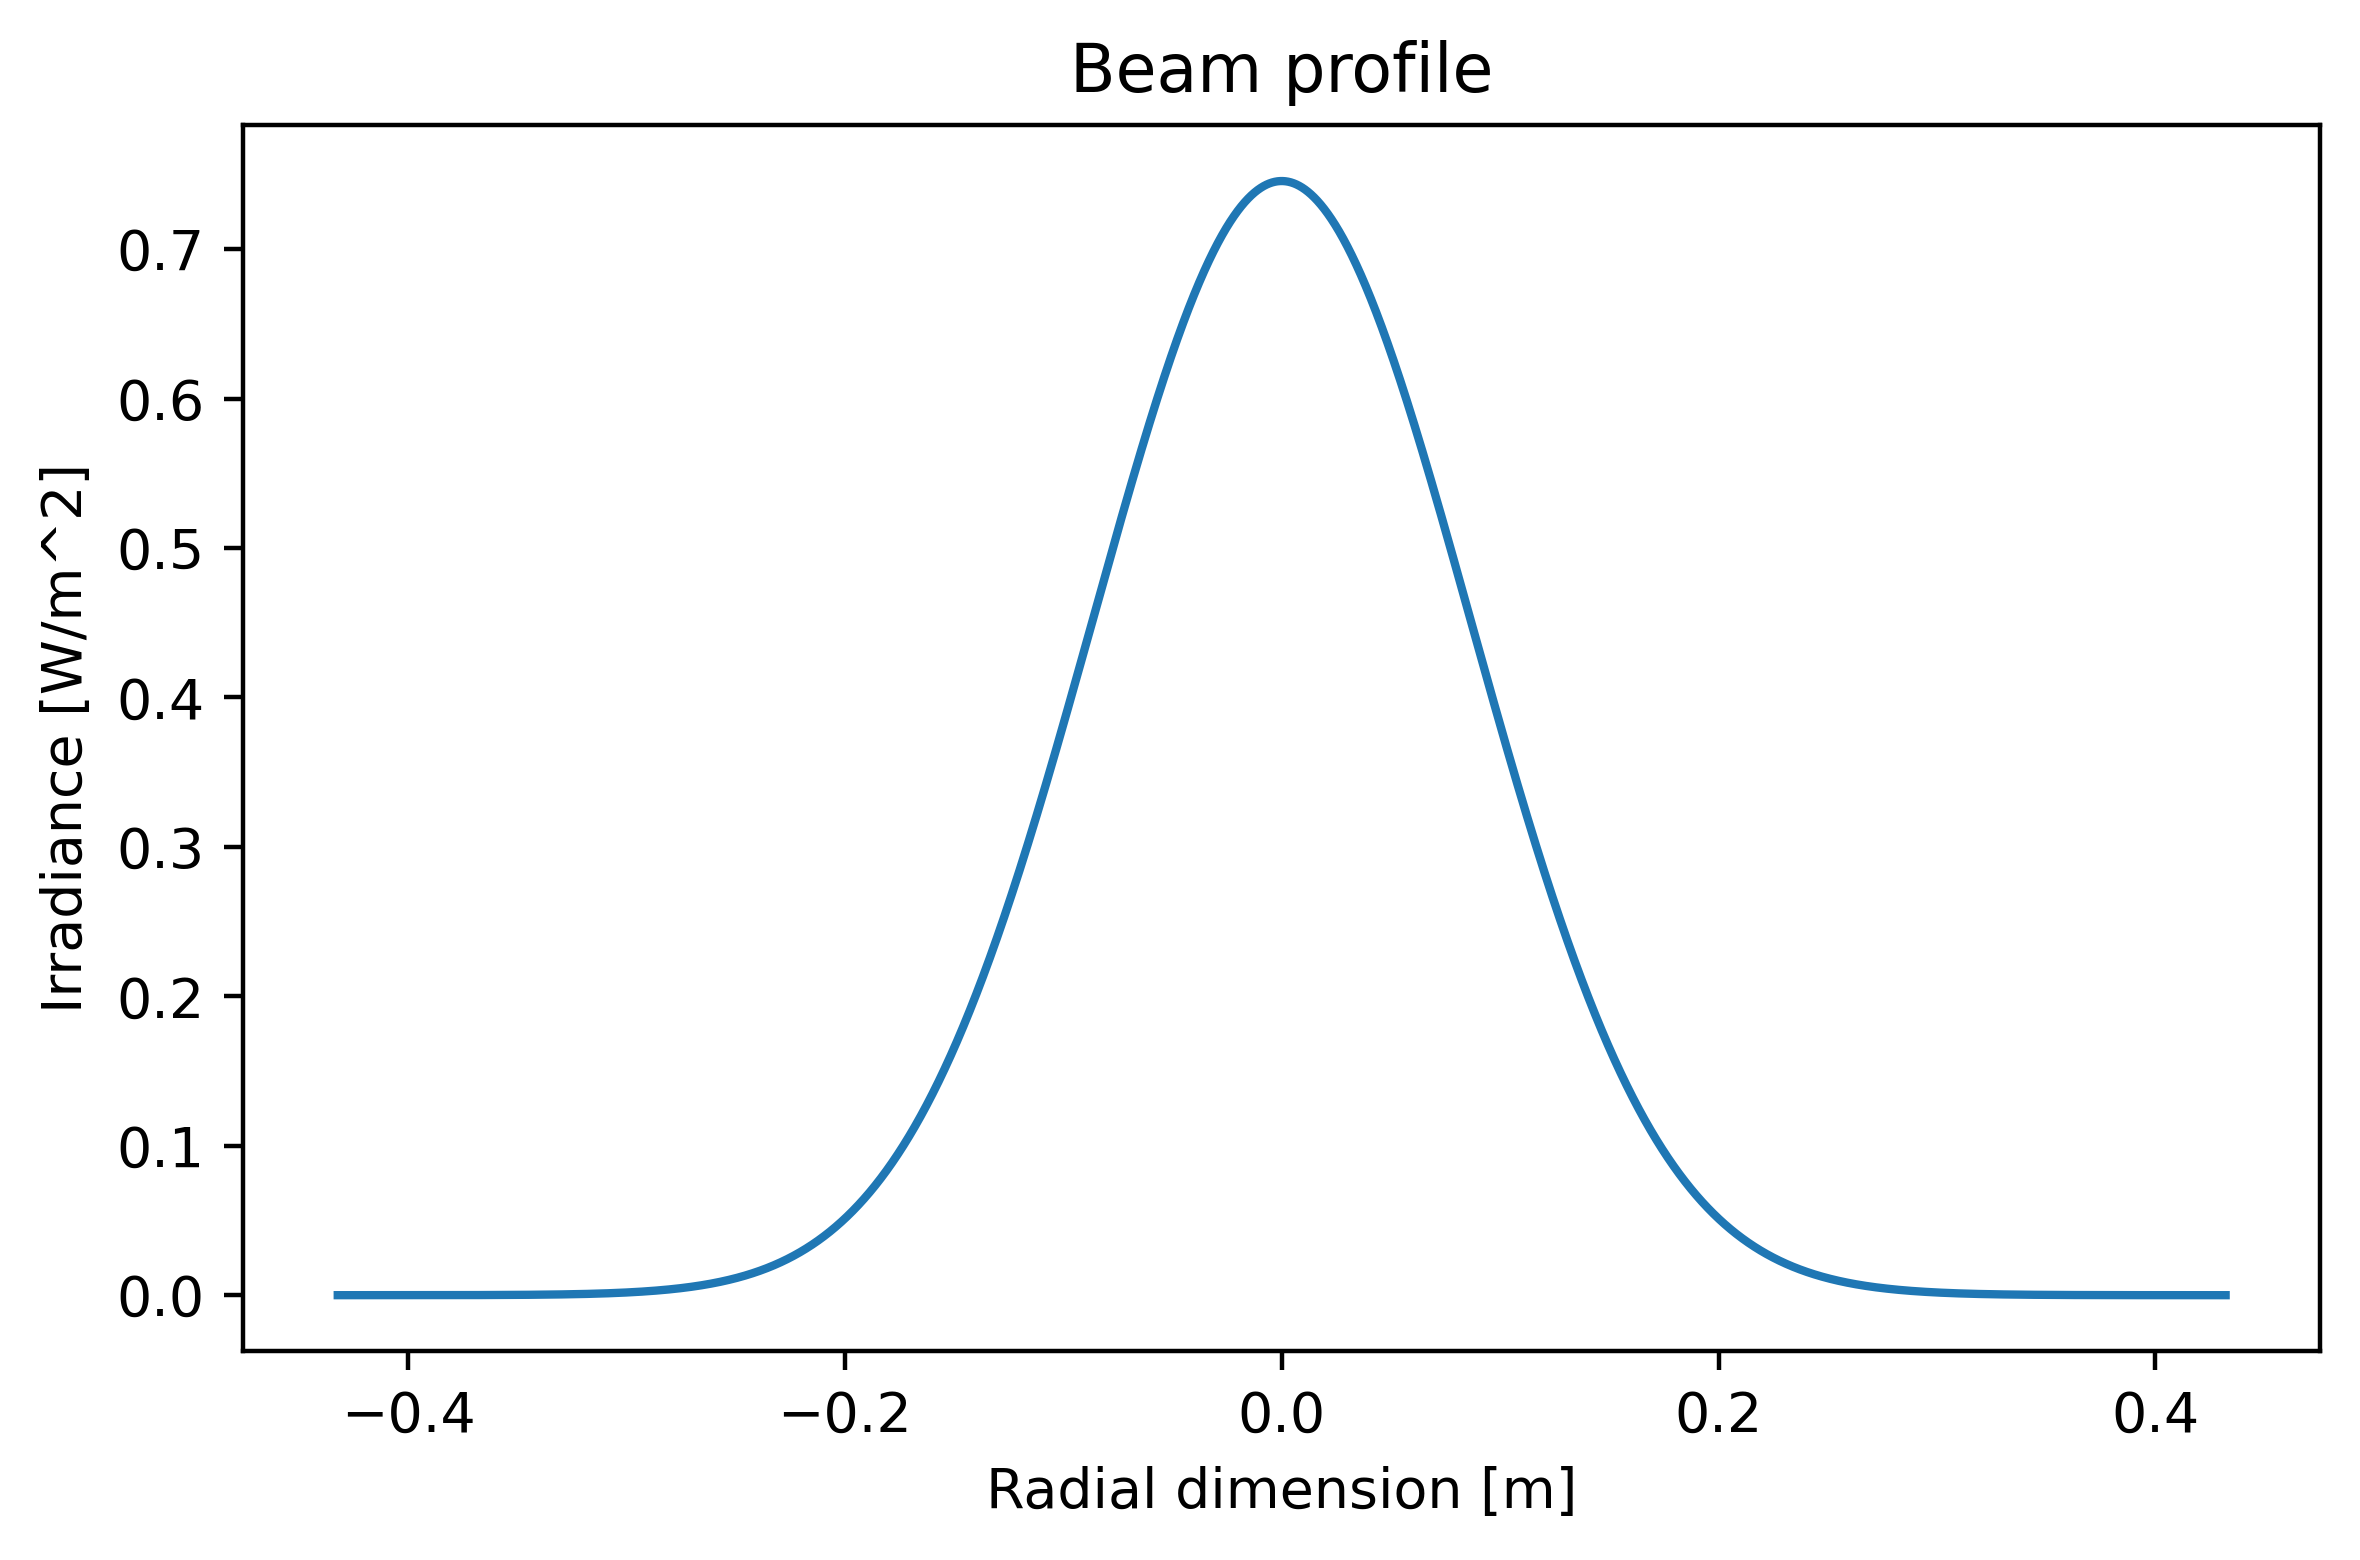

In [7]:
# Plot transverse beam profile
r = np.linspace(-5*sigma, 5*sigma, 100000)

f = I_0 * np.exp(-r**2/2/sigma**2)  # [W/m^2]

fig = plt.figure(dpi=400)
ax = fig.add_subplot(111)
ax.plot(r, f)
ax.set_xlabel('Radial dimension [m]')
ax.set_ylabel('Irradiance [W/m^2]')
ax.set_title('Beam profile')
plt.tight_layout()
plt.show()

In [8]:
# Pick a typical scene

n = 1e6  # [m-3]
dR = 0.1  # [m]
A = np.pi * R**2  # [m^2]
V = A * dR  # [m^3] sample volume

N_init = n * V  # expected number of particles in sample volume
print('Volume: {:.5f} m-3'.format(V))
print('Expected number of particles in first volume: {:.0f}'.format(N_init))

Volume: 0.00939 m-3
Expected number of particles in first volume: 9388


In [9]:
k = np.arange(1, 10, 1)
N = N_init * k
delta = 1/np.sqrt(N) * CV_IA

# delta = np.sqrt(N) * Var_IA

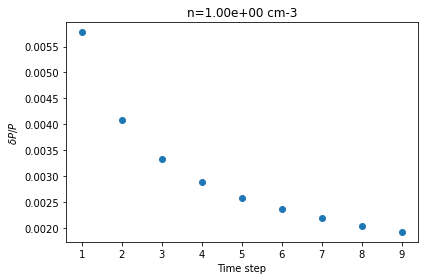

In [10]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(k, delta, 'o')
ax.set_xlabel('Time step')
ax.set_ylabel('$\delta P/P$')
ax.set_title('n={:.2e} cm-3'.format(n / 1e6))
plt.tight_layout()
plt.show()

### Add in 3rd dimension (pulse and range bin)

Let's assume pulse shape is Gaussian too (could be arbitrary). This is given by the normalized gaussian
$$f(z)=\frac{1}{\sqrt{2\pi}\sigma_z}\exp\left(-\frac{z^2}{2\sigma_z^2}\right)$$
The irradiance function is found by convolving the pulse shape with the range bin with width $\Delta R$:
$$I(r,z)=I_0\exp\left(-\frac{r^2}{2\sigma^2}\right)\left[f(z)\ast\textbf{1}_{[0,\Delta R]}(z)\right]$$
where $\textbf{1}$ is a boxcar function defined as unity over $[0,\Delta R]$ and zero elsewhere.
The expectation value changes to 
$$E[I]=\int_V I(r,z)dV=\frac{1}{V}\int_A I(r)dA \int_{z_a}^{z_b}f(z)\ast\textbf{1}_{[0,\Delta R]}(z)dz=E[I_A I_z]$$
We know the lefthand side solution (above), just need to solve righthand side. 
This is not an analytic solution so it requires numerical integration. Note that
$$E[I_A I_z] = E[I_A]E[I_z]$$
and
$$\mathrm{Var}(I_AI_z)=E[I_A^2]E[I_z^2] - (E[I_A])^2(E[I_z])^2$$

In [11]:
# Create pulse shape (gaussian)
FWHM = 750e-12  # [s]
c = 3e8  # [m/s]
FWHM = FWHM * c / 2  # [m] convert to range
sigma_z = FWHM / 2.355  # [m] 
dR = 0.004  # [m]
z_min = -50  # [m]
z_max = 50  # [m]

print('Pulse width: {:.2f} m'.format(2*sigma_z))

z_arr = np.linspace(z_min, z_max, 500000)  # [m]
f = 1 / np.sqrt(2 * np.pi) / sigma_z * np.exp(-z_arr**2 / 2 / sigma_z**2)

dz = np.diff(z_arr)[0]  # [m]
# num_steps_b = np.ceil(dR / dz).astype(int)
z_b = np.arange(z_min, z_max, dz)
box = ((z_b >= 0) & (z_b <= dR)).astype(float)

Pulse width: 0.10 m


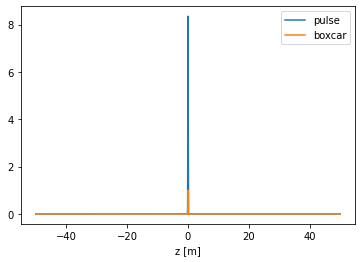

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(z_arr, f, label='pulse')
ax.plot(z_b, box, label='boxcar')
ax.set_xlabel('z [m]')
plt.legend()
plt.show()

In [13]:
I_z = convolve(f, box, mode='same') * dz

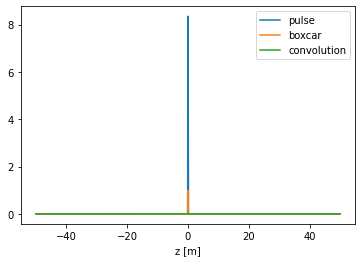

In [14]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(z_arr, f, label='pulse')
ax.plot(z_b, box, label='boxcar')
ax.plot(z_arr, I_z, label='convolution')
ax.set_xlabel('z [m]')
plt.legend()
plt.show()

In [15]:
# locate 1/e^2 width of convolved product

mag_e = 1 / math.exp(1)**2 * np.max(I_z)

g = I_z - mag_e
idx = np.where(np.diff(np.sign(g)) != 0)[0]
idx_cross = [idx[0], idx[1]]
z_cross = z_arr[idx_cross]
width = np.diff(z_cross)[0]  # [m]

print('Effective width: {:.2f} m'.format(width))

Effective width: 0.19 m


In [16]:
mask = np.arange(idx[0], idx[1])
f_eval = I_z[mask]
x = z_arr[mask]

integral = np.trapz(f_eval, x)  # [W/m^2 m]
integral_2 = np.trapz(f_eval**2, x)  # [(W/m^2)^2 m]
E_Iz = integral / width  # [W/m^2] expected value of the z dimension of the pulse
E_Iz2 = integral_2 / width  # [(W/m^2)^2] second moment

Var_Iz = E_Iz2 - (E_Iz)**2  # [(W/m^2)^2]
CV_Iz = np.sqrt(Var_Iz) / E_Iz 

print('Variance of I_z: {:.5f} (W/m)^2'.format(Var_Iz))
print('Coefficient of Variation: {:.2f}'.format(CV_Iz))

Variance of I_z: 0.00009 (W/m)^2
Coefficient of Variation: 0.48


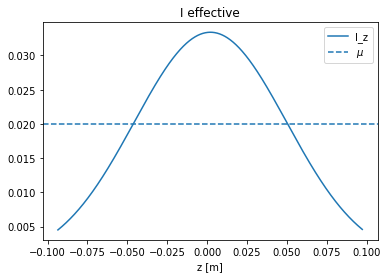

In [17]:
plt.plot(x, f_eval, label='I_z')
plt.axhline(y=E_Iz, label='$\mu$', linestyle='--')
plt.title('I effective')
plt.xlabel('z [m]')
plt.legend()
plt.show()

In [18]:
Var_I = E_IA2 * E_Iz2 - E_IA**2 * E_Iz**2
CV_I = np.sqrt(Var_I) / E_IA / E_Iz

print('Variance of I: {:.5f} (W/m)^2'.format(Var_I))
print('Coefficient of Variation: {:.2f}'.format(CV_I))

Variance of I: 0.00003 (W/m)^2
Coefficient of Variation: 0.79


In [19]:
# Pick a typical scene

n = 1e8  # [m-3]
A = np.pi * w**2  # [m^2]
dR = width  # [m]
V = A * dR  # [m^3] sample volume

print('Sample volume:\n')
print('Area: {:.2f} m^2'.format(A))
print('Transverse diameter: {:.2f} m'.format(w))
print('Depth: {:.2f} m'.format(dR))
print('Volume: {:.2f} m^3  or {:.0f} cm^3'.format(V, V*1e6))

N_init = n * V  # expected number of particles in sample volume

print('Expected number of particles in first volume: {:.2f}'.format(N_init))

k = np.arange(1, 10, 1)
N = N_init * k
delta = 1/np.sqrt(N) * CV_I

Sample volume:

Area: 0.09 m^2
Transverse diameter: 0.17 m
Depth: 0.19 m
Volume: 0.02 m^3  or 17932 cm^3
Expected number of particles in first volume: 1793170.29


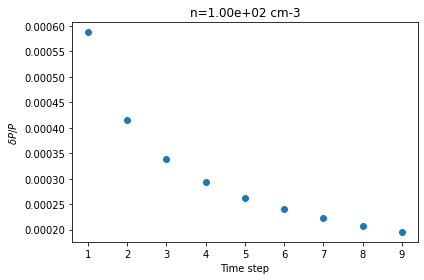

In [20]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(k, delta, 'o')
ax.set_xlabel('Time step')
ax.set_ylabel('$\delta P/P$')
ax.set_title('n={:.2e} cm-3'.format(n / 1e6))
plt.tight_layout()
plt.show()

### Particle Size Distribution

Extending this to particle size distribution. I use the gamma distribution for PSD $n'$ [m-3 m-1]:
$$n'(D)=N_0'D^{\mu}\exp(-\Lambda D)$$
where $D$ is particle diameter, $N_0'$ is a scaling term, $\mu$ shapes the distribution, and $\Lambda$ defines the exponential decay (how many large particles are allowed). To find number concentration [m-3], integrate the PSD
$$n=\int_{0}^{\infty} n'(D) dD$$

The PSD can be normalized to get the probability distribution function $g$ [m-1]:
$$g(D)=\frac{n'(D)}{n}$$

Lastly, we find expectation values and variances the same way as before:
$$E[S]=\int_{0}^{\infty}\frac{d\sigma_b(s)}{d\Omega}g(s)ds$$
where $\frac{d\sigma_b(s)}{d\Omega}\approx\pi s^2$ in the geometric regime and $S$ is the random variable representation of $\frac{d\sigma_b}{d\Omega}$.
$$\mathrm{Var}(S)=E[S^2] - (E[S])^2$$

We can incorporate this into the overall variance calculation since size is independent from location
$$\mathrm{Var}(I_AI_zS)=E[I_A^2]E[I_z^2]E[S^2] - (E[I_A])^2(E[I_z])^2(E[S])^2$$
and
$$CV_{IS} = \frac{\sqrt{\mathrm{Var}(I_AI_zS)}}{E[I_A]E[I_z]E[I_S]}$$

Last thing to note. Geometric scattering regime is reasonable when size parameter $x=\frac{\pi D}{\lambda}\geq20$ about. So this is around 5 microns. 

Let's generalize this formulation. So the true gamma distribution pdf is
$$f(x)=\frac{\beta^{\alpha}}{\Gamma(\alpha)}x^{\alpha-1}\exp(-\beta x)$$
We can use this parameterization to come up with a scaling factor $N_0$ [cm-3] that more directly scales according to a realistic number concentration:
$$n'(D)=N_0f(x)$$

In [64]:
D = np.logspace(-8, -2, 10000)  # [m]
beta = 2e6  # [m-1] rate (shift location of peak)
alpha = 21  # shape  (change overall shape)
N_0 = 500  # [cm-3]

f_gamma = beta**alpha / sp.gamma(alpha) * D**(alpha-1) * np.exp(-beta*D)  # [m-1]
n_dist = N_0 * f_gamma  # [cm-3 m-1]

N_tot = np.trapz(n_dist, D)  # [cm-3]
print('Total number concentration: {:.2e} cm-3'.format(N_tot))

Total number concentration: 5.00e+02 cm-3


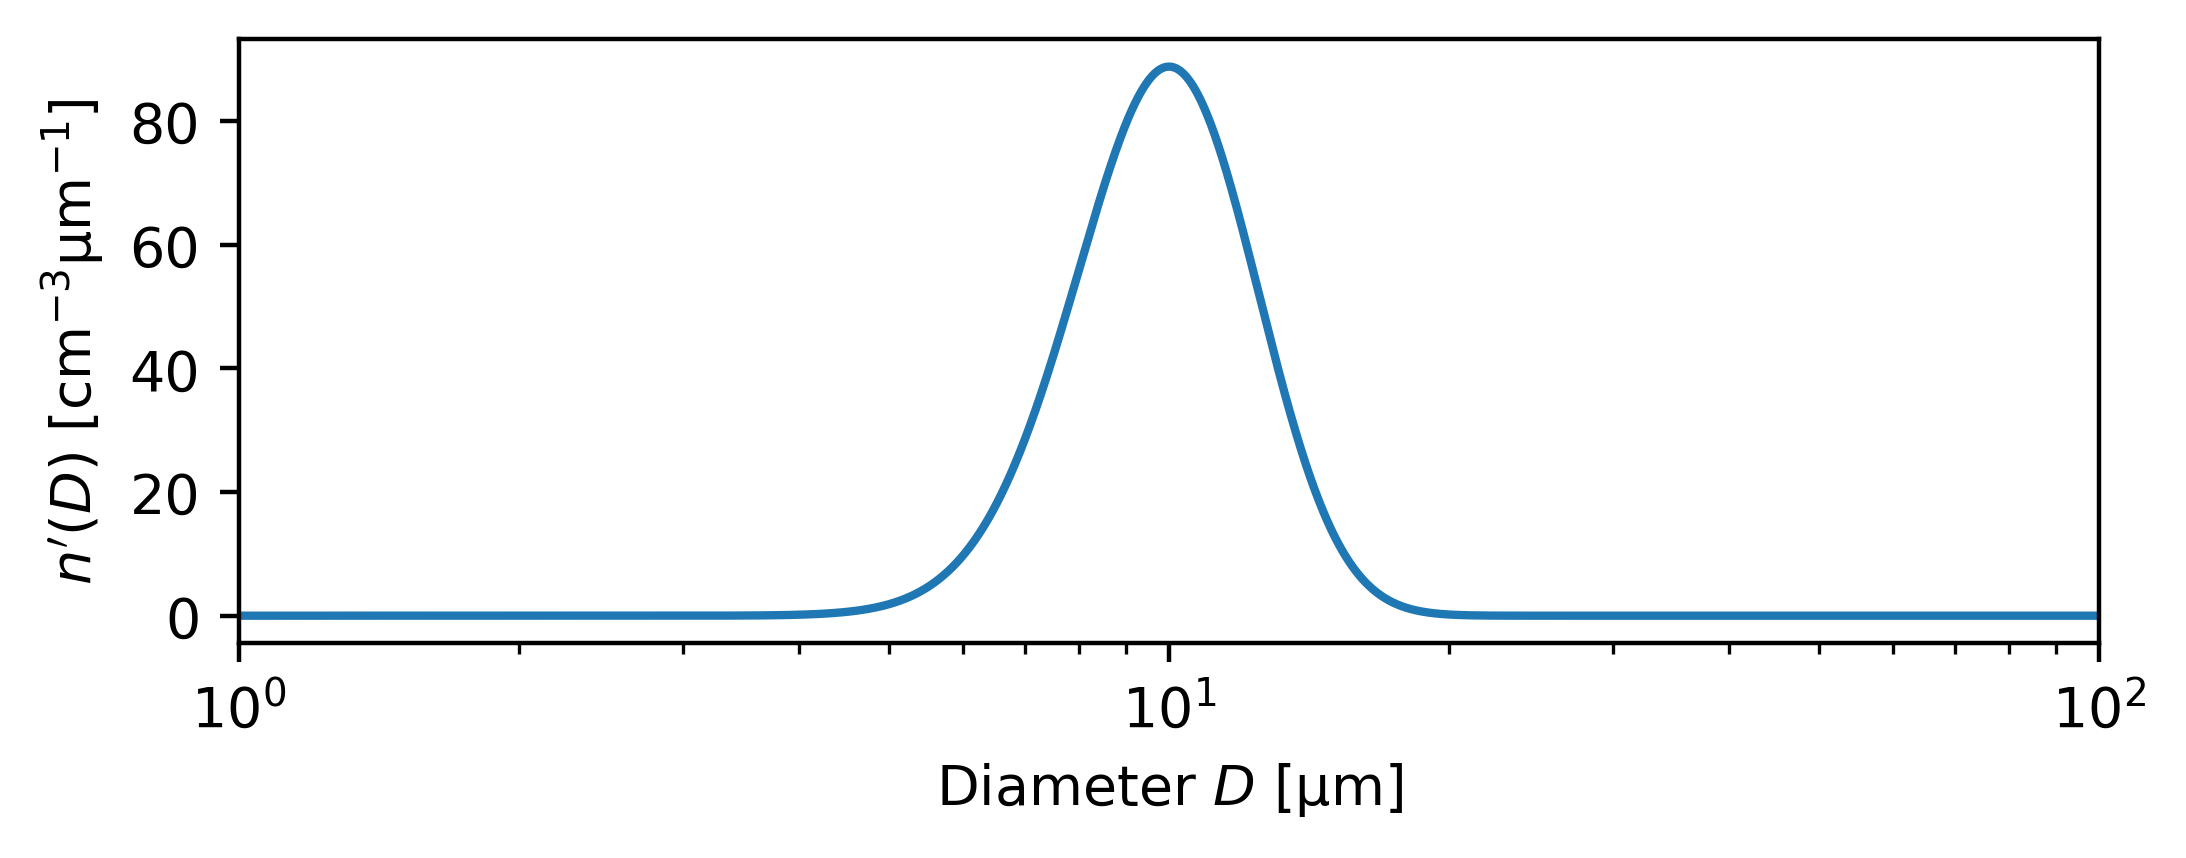

In [65]:
fig = plt.figure(dpi=400, figsize=(6, 2))
ax = fig.add_subplot(111)
ax.plot(D*1e6, n_dist/1e6)
ax.set_xlabel('Diameter $D$ [$\mathrm{\mu m}$]')
ax.set_ylabel("$n'(D)$ [$\mathrm{cm}^{-3} \mathrm{\mu m}^{-1}$]")
ax.set_xscale('log')
ax.set_xlim([1e0, 1e2])
# ax.set_yscale('log')
# ax.set_ylim([1e-6,1e2])
plt.show()

# TODO: Should integral be over D/2 or D?

In [35]:
diff_xsec = np.pi * (D/2)**2  # [m^2 sr-1]
f_int = diff_xsec * n_dist / (N_tot*1e6)

E_S = np.trapz(f_int, D)  # [m^2 sr-1]
print('Expected differential-backscatter cross section: {:.2e} m^2 sr-1'.format(E_S))

E_S2 = np.trapz(f_int**2, D)  # [(m^2 sr-1)^2]

Var_S = E_S2 - E_S**2
print('Variance in differential-backscatter cross section: {:.2e} (m^2 sr-1)^2'.format(Var_S))

CV_S = np.sqrt(Var_S)/E_S
print('Coefficient of variation for differential-backscatter cross section: {:.2f}'.format(CV_S))

Expected differential-backscatter cross section: 9.07e-17 m^2 sr-1
Variance in differential-backscatter cross section: 9.84e-28 (m^2 sr-1)^2
Coefficient of variation for differential-backscatter cross section: 345.84


In [36]:
CV_IS = np.sqrt(CV_I**2 + CV_S**2 + (CV_I**2)*(CV_S**2))
print('Coefficient of Variation I: {:.2f}'.format(CV_I))
print('Coefficient of Variation S: {:.2f}'.format(CV_S))
print('Effective Coefficient of Variation: {:.2f}'.format(CV_IS))

Coefficient of Variation I: 0.79
Coefficient of Variation S: 345.84
Effective Coefficient of Variation: 439.99


In [37]:
# Pick a typical scene

n = N_tot * 1e6  # [m-3]
A = np.pi * w**2  # [m^2]
dR = width  # [m]
V = A * dR  # [m^3] sample volume

print('Sample volume:\n')
print('Area: {:.2f} m^2'.format(A))
print('Transverse diameter: {:.2f} m'.format(w))
print('Depth: {:.2f} m'.format(dR))
print('Volume: {:.5f} m^3  or {:.0f} cm^3'.format(V, V*1e6))

N_init = n * V  # expected number of particles in sample volume

print('Expected number of particles in first volume: {:.2f}'.format(N_init))

k = np.arange(1, 50, 1)
N = N_init * k
delta = 1/np.sqrt(N) * CV_IS

Sample volume:

Area: 0.09 m^2
Transverse diameter: 0.17 m
Depth: 0.19 m
Volume: 0.01793 m^3  or 17932 cm^3
Expected number of particles in first volume: 1793170.86


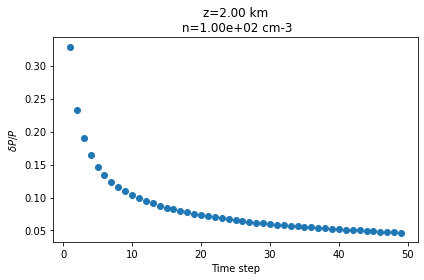

In [38]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(k, delta, 'o')
ax.set_xlabel('Time step')
ax.set_ylabel('$\delta P/P$')
ax.set_title('z={:.2f} km\n n={:.2e} cm-3'.format(z/1e3, n/1e6))
plt.tight_layout()
plt.show()

# Functionalizing Things

In [96]:
class DiscreteUncertainty:
    def __init__(self, params):
        self.w_0 = params['w_0']  # [m]
        self.expand = params['expand']  # magnification
        self.lamb = params['lamb']  # [m]
        self.PRF = params['PRF']  # [Hz]
        self.c = params['c']  # [m/s]
        self.z_target = params['z_target']  # [m]
        
        self.P_avg = params['P_avg']  # [W] average power
        self.t_end = params['t_end']  # [s]
        
        # Pulse
        self.FWHM = params['FWHM']  # [s]
        self.dR = params['dR']  # [m]
        self.z_min = params['z_min']  # [m]
        self.z_max = params['z_max']  # [m]
        
        # Scene
        # self.n = params['n']  # [m-3]
        self.v = params['v']  # [m/s] advection rate
        self.N_0 = params['N_0']  # [cm-3] number concentration
        self.beta = params['beta']  # rate for gamma distribution
        self.alpha = params['alpha']  # shape for gamma distribution

    def calc_beam_params(self):
        # Calculate beam params
    
        unamb_range = (1 / self.PRF) * self.c / 2
        z = np.linspace(0, unamb_range, 10000)
        
        w_0_exp = self.w_0 * self.expand  # magnify waist
        
        # w = w_0_exp * np.sqrt(1 + (self.lamb * z / np.pi / (w_0_exp**2))**2)
        w = self.beam_waist(w_0_exp, self.lamb, z)
        
        idx_target = np.argmin(abs(z - self.z_target))
        w_target = w[idx_target]
        
        print('\nFull-width waist: {:.2f} m'.format(2 * w_target))
        
        theta = self.beam_divergence(w_0_exp, self.lamb)
        print('Full angle divergence: {:.2f} urad'.format(2 * theta * 1e6))

        return w_target

    def calc_transverse_I(self, w_target):
        # Calculate variance of I in the transverse (2D) dimension
        R = w_target
        sigma = w_target
        I_0 = self.peak_irradiance(self.P_avg, sigma)  # [W/m^2]
        
        print('\n2D Calculations')
        print('Peak irradiance: {:.3f} W/m'.format(I_0))
        
        E_IA = self.gaussian_first_moment(I_0, sigma, R)  # [W/m^2]
        E_IA2 = self.gaussian_second_moment(I_0, sigma, R)  # [(W/m^2)^2]
        
        Var_IA = self.calc_variance(E_IA, E_IA2)  # [(W/m^2)^2]
        
        print('Expected irradiance: {:.3f} W/m^2'.format(E_IA))
        
        CV_IA = self.calc_CV(Var_IA, E_IA)
        
        print('Coefficient of variation: {:.3f}'.format(CV_IA))

        return E_IA, E_IA2

    def calc_z_I(self):
        # Calculate variance of I in the depth dimension (pulse)
        FWHM = self.FWHM * self.c / 2  # [m] convert to range
        sigma_z = FWHM / 2.355  # [m] 

        print('\nDepth Dimension (pulse)')
        print('Pulse width: {:.2f} m'.format(2 * sigma_z))
        
        # Create pulse shape (gaussian)
        z = np.linspace(self.z_min, self.z_max, 100000)  # [m]
        f = 1 / np.sqrt(2 * np.pi) / sigma_z * np.exp(-z**2 / 2 / sigma_z**2)
        
        # Create range bin (boxcar)
        dz = np.diff(z)[0]  # [m]
        z_b = np.arange(z_min, z_max, dz)
        box = ((z_b >= 0) & (z_b <= dR)).astype(float)
        
        # Create effective depth volume (convolution of pulse and range bin)
        I_z = convolve(f, box, mode='same') * dz
        
        # Locate 1/e^2 width of convolved product
        mag_e = 1 / math.exp(1)**2 * np.max(I_z)
        g = I_z - mag_e
        idx = np.where(np.diff(np.sign(g)) != 0)[0]
        idx_cross = [idx[0], idx[1]]
        z_cross = z[idx_cross]
        width = np.diff(z_cross)[0]  # [m]
        
        print('Effective width: {:.2f} m'.format(width))
        
        # Compute expectation value
        mask = np.arange(idx[0], idx[1])
        f_eval = I_z[mask]
        x = z[mask]
        
        E_Iz = self.general_moment(f_eval, x, width)  # expected value of the z dimension of the pulse
        E_Iz2 = self.general_moment(f_eval**2, x, width)  # second moment
        
        Var_Iz = self.calc_variance(E_Iz, E_Iz2)
        CV_Iz = self.calc_CV(Var_Iz, E_Iz)
        
        print('Variance of I_z: {:.2f}'.format(Var_Iz))
        print('Coefficient of Variation: {:.2f}'.format(CV_Iz))

        return E_Iz, E_Iz2, width

    def calc_uncertainty_I(self, E_IA2, E_Iz2, E_IA, E_Iz):
        Var_I = E_IA2 * E_Iz2 - E_IA**2 * E_Iz**2
        CV_I = np.sqrt(Var_I) / E_IA / E_Iz
        
        print('\nVariance of I: {:.2f}'.format(Var_I))
        print('Coefficient of Variation: {:.2f}'.format(CV_I))

        return CV_I

    def calc_uncertainty_S(self):
        D = np.logspace(-8, -2, 10000)  # [m]
        
        f_gamma = self.beta**self.alpha / sp.gamma(self.alpha) * D**(self.alpha-1) * np.exp(-self.beta*D)
        n_dist = self.N_0 * f_gamma  # [cm-3 m-3]
        
        N_tot = np.trapz(n_dist, D)  # [cm-3]
        print('Total number concentration: {:.2e} cm-3'.format(N_tot))

        diff_xsec = np.pi * (D/2)**2  # [m^2 sr-1]
        f_int = diff_xsec * n_dist / (N_tot*1e6)
        
        E_S = np.trapz(f_int, D)  # [m^2 sr-1]
        print('Expected differential-backscatter cross section: {:.2e} m^2 sr-1'.format(E_S))
        
        E_S2 = np.trapz(f_int**2, D)  # [(m^2 sr-1)^2]
        
        Var_S = E_S2 - E_S**2
        print('Variance in differential-backscatter cross section: {:.2e} (m^2 sr-1)^2'.format(Var_S))
        
        CV_S = np.sqrt(Var_S)/E_S
        print('Coefficient of variation for differential-backscatter cross section: {:.2f}'.format(CV_S))

        return CV_S, N_tot, n_dist, D

    def calc_uncertainty_IS(self, CV_I, CV_S):
        CV_IS = np.sqrt(CV_I**2 + CV_S**2 + (CV_I**2)*(CV_S**2))
        print('Coefficient of Variation I: {:.2f}'.format(CV_I))
        print('Coefficient of Variation S: {:.2f}'.format(CV_S))
        print('Effective Coefficient of Variation: {:.2f}'.format(CV_IS))

        return CV_IS

    def sample_volume(self, w_target, width, CV_IS, N_tot):
        # Calculate uncertainty when treating sample volume as equivalently volumetric (integral vs. discrete sum)
        
        A = np.pi * w_target**2  # [m^2]
        dR = width  # [m]
        V = A * dR  # [m^3] sample volume
        
        print('\nSample volume:\n')
        print('Distance: {:.2f} km'.format(self.z_target / 1e3))
        print('Number concentration: {:.0f} m-3'.format(N_tot))
        print('Area: {:.2f} m^2'.format(A))
        print('Transverse diameter: {:.2f} m'.format(2 * w_target))
        print('Depth: {:.2f} m'.format(dR))
        print('Volume: {:.2f} m^3'.format(V))
        
        N_init = (N_tot*1e6) * V  # expected number of particles in sample volume
        
        print('Expected number of particles: {:.2f}\n'.format(N_init))

        k_end = np.round(self.t_end * self.v / (2 * w_target)).astype(int)
        
        k = np.arange(0, k_end-1, 1)
        N = N_init * k
        delta = 1/np.sqrt(N) * CV_IS
        
        t = k / self.v * (2 * w_target)

        return delta, t       

    """ Calculators """    
    @staticmethod
    def beam_waist(w_0, lamb, z):
        # Returns beam waist according to gaussian beam propagation
        return w_0 * np.sqrt(1 + (lamb * z / np.pi / (w_0**2))**2)

    @staticmethod
    def beam_divergence(w_0, lamb):
        # Returns beam divergence (radians) according to gaussian beam propagation
        return lamb / np.pi / w_0

    @staticmethod
    def peak_irradiance(P_avg, sigma):
        # Return peak irradiance of 2D gaussian beam
        return P_avg / 2 / np.pi / sigma**2  # [W/m^2]

    @staticmethod
    def gaussian_first_moment(I_0, sigma, R):
        # Return first moment i.e., E[X]
        return 2 * I_0 * (sigma / R)**2 * (1 - np.exp(-R**2 / 2 / sigma**2))  # [W/m^2]

    @staticmethod
    def gaussian_second_moment(I_0, sigma, R):
        # Return second moment i.e., E[X^2]
        return I_0**2 * (sigma / R)**2 * (1 - np.exp(-R**2 / sigma**2))  # [(W/m^2)^2]

    @staticmethod
    def general_moment(f, x, width):
        # Return moment (first f, second f^2, third etc.)
        integral = np.trapz(f, x) 
        return integral / width  # expected value of the z dimension of the pulse

    @staticmethod
    def calc_variance(E, E2):
        # Return variance Var = E[X^2] - (E[X])^2
        """
        E: E[X] first moment
        E2: E[X^2] second moment
        """
        return E2 - E**2

    @staticmethod
    def calc_CV(Var, E):
        # Return coefficient of variation CV = sqrt(Var(X)) / E[X]
        return np.sqrt(Var) / E

In [113]:
# Parameters
params_original = {
    'w_0': 42e-6,  # [m]
    'expand': 46.65,  # magnification (5 * 9.33)
    'lamb': 532e-9,  # [m]
    'PRF': 14.3e3,  # [Hz]
    'c': 3e8,  # [m/s]
    'z_target': 2e3,  # [m]
    'P_avg': 35e-3,  # [W] average power
    'FWHM': 750e-12,  # [s]
    'dR': 0.1,  # [m]
    'z_min': -50,  # [m]
    'z_max': 50,  # [m]
    'v': 5,  # [m/s] advection rate
    'N_0': 500,  # [cm-3] number concentration
    'beta': 2e6,  # rate
    'alpha': 21,  # shape    
    't_end': 5  # [s] total time
}

Total number concentration: 5.00e+02 cm-3
Expected differential-backscatter cross section: 9.07e-17 m^2 sr-1
Variance in differential-backscatter cross section: 9.84e-28 (m^2 sr-1)^2
Coefficient of variation for differential-backscatter cross section: 345.84


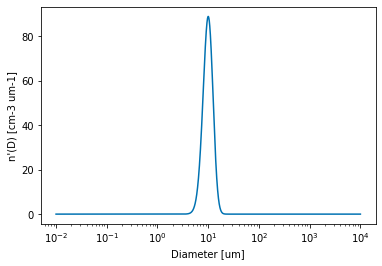

In [114]:
# Check gamma distribution make sense before running calculation
params = params_original.copy()

du = DiscreteUncertainty(params)
CV_S, N_tot, n_dist, D = du.calc_uncertainty_S()

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(D*1e6, n_dist/1e6)
ax.set_xlabel('Diameter [um]')
ax.set_ylabel("n'(D) [cm-3 um-1]")
ax.set_xscale('log')
# ax.set_yscale('log')
# ax.set_ylim([1e-6,1e2])
plt.show()

In [125]:
# Iterate through different ranges
params = params_original.copy()

zs_start = 1e3
zs_end = 7e3
z_step = 2e3
zs = np.arange(zs_start, zs_end + z_step, z_step)

deltas = []
ts = []
for i in range(len(zs)):
    params['z_target'] = zs[i]
    
    du = DiscreteUncertainty(params)
    w_target = du.calc_beam_params()
    E_IA, E_IA2 = du.calc_transverse_I(w_target)
    E_Iz, E_Iz2, width = du.calc_z_I()
    CV_I = du.calc_uncertainty_I(E_IA2, E_Iz2, E_IA, E_Iz)
    CV_S, N_tot, n_dist, D = du.calc_uncertainty_S()
    CV_IS = du.calc_uncertainty_IS(CV_I, CV_S)
    delta, t = du.sample_volume(w_target, width, CV_IS, N_tot)

    deltas.append(delta)
    ts.append(t)

N_tot_1 = N_tot
# print(deltas)

# deltas = np.array(deltas)


Full-width waist: 0.17 m
Full angle divergence: 172.86 urad

2D Calculations
Peak irradiance: 0.746 W/m
Expected irradiance: 0.587 W/m^2
Coefficient of variation: 0.144

Depth Dimension (pulse)
Pulse width: 0.10 m
Effective width: 0.30 m
Variance of I_z: 0.08
Coefficient of Variation: 0.44

Variance of I: 0.03
Coefficient of Variation: 0.47
Total number concentration: 5.00e+02 cm-3
Expected differential-backscatter cross section: 9.07e-17 m^2 sr-1
Variance in differential-backscatter cross section: 9.84e-28 (m^2 sr-1)^2
Coefficient of variation for differential-backscatter cross section: 345.84
Coefficient of Variation I: 0.47
Coefficient of Variation S: 345.84
Effective Coefficient of Variation: 382.14

Sample volume:

Distance: 1.00 km
Number concentration: 500 m-3
Area: 0.02 m^2
Transverse diameter: 0.17 m
Depth: 0.30 m
Volume: 0.01 m^3
Expected number of particles: 3496782.43


Full-width waist: 0.52 m
Full angle divergence: 172.86 urad

2D Calculations
Peak irradiance: 0.083 W/m


C:\Users\gkirc\AppData\Local\Temp\ipykernel_9880\3005575888.py:180: RuntimeWarning: divide by zero encountered in divide
  delta = 1/np.sqrt(N) * CV_IS


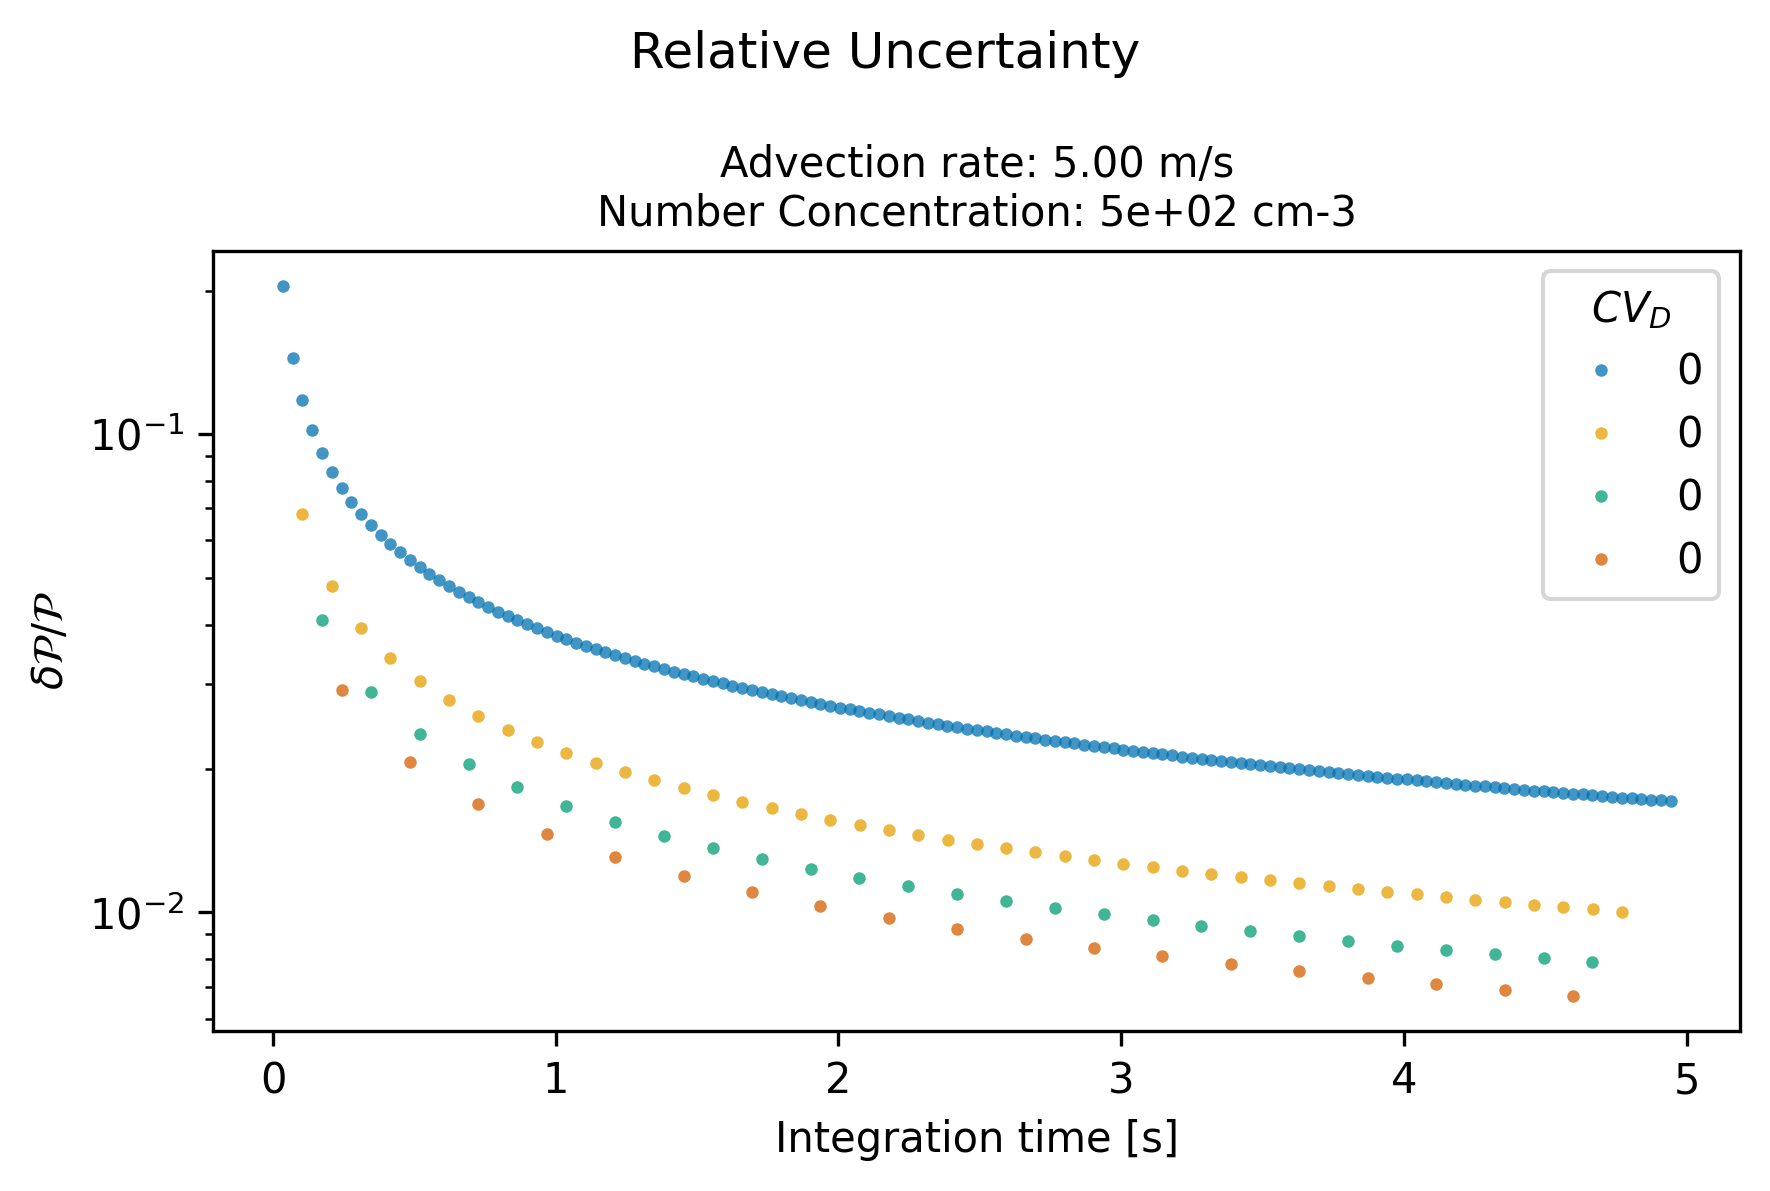

In [126]:
fig = plt.figure(dpi=300)
ax = fig.add_subplot(111)
for i in range(len(deltas)):
    ax.plot(ts[i], deltas[i], 'o', alpha=0.75, markersize=3, markeredgewidth=0, label='{:.0f}'.format(1/np.sqrt(alphas[i])))
ax.set_xlabel('Integration time [s]')
ax.set_ylabel('$\delta\mathcal{P}/\mathcal{P}$')
fig.suptitle('Relative Uncertainty')
ax.set_title('Advection rate: {:.2f} m/s\nNumber Concentration: {:.0e} cm-3'.format(params['v'], N_tot), fontsize=10)
ax.set_yscale('log')
plt.legend(title=r'$CV_D$')
plt.tight_layout()
plt.show()

In [127]:
# Iterate through different ranges
params = params_original.copy()
params['N_0'] = 5  # [cm-3]

deltas_new = []
ts_new = []
for i in range(len(zs)):
    params['z_target'] = zs[i]
    
    du = DiscreteUncertainty(params)
    w_target = du.calc_beam_params()
    E_IA, E_IA2 = du.calc_transverse_I(w_target)
    E_Iz, E_Iz2, width = du.calc_z_I()
    CV_I = du.calc_uncertainty_I(E_IA2, E_Iz2, E_IA, E_Iz)
    CV_S, N_tot, n_dist, D = du.calc_uncertainty_S()
    CV_IS = du.calc_uncertainty_IS(CV_I, CV_S)
    delta, t = du.sample_volume(w_target, width, CV_IS, N_tot)

    deltas_new.append(delta)
    ts_new.append(t)

N_tot_2 = N_tot


Full-width waist: 0.17 m
Full angle divergence: 172.86 urad

2D Calculations
Peak irradiance: 0.746 W/m
Expected irradiance: 0.587 W/m^2
Coefficient of variation: 0.144

Depth Dimension (pulse)
Pulse width: 0.10 m
Effective width: 0.30 m
Variance of I_z: 0.08
Coefficient of Variation: 0.44

Variance of I: 0.03
Coefficient of Variation: 0.47
Total number concentration: 5.00e+00 cm-3
Expected differential-backscatter cross section: 9.07e-17 m^2 sr-1
Variance in differential-backscatter cross section: 9.84e-28 (m^2 sr-1)^2
Coefficient of variation for differential-backscatter cross section: 345.84
Coefficient of Variation I: 0.47
Coefficient of Variation S: 345.84
Effective Coefficient of Variation: 382.14

Sample volume:

Distance: 1.00 km
Number concentration: 5 m-3
Area: 0.02 m^2
Transverse diameter: 0.17 m
Depth: 0.30 m
Volume: 0.01 m^3
Expected number of particles: 34967.82


Full-width waist: 0.52 m
Full angle divergence: 172.86 urad

2D Calculations
Peak irradiance: 0.083 W/m
Expe

C:\Users\gkirc\AppData\Local\Temp\ipykernel_9880\3005575888.py:180: RuntimeWarning: divide by zero encountered in divide
  delta = 1/np.sqrt(N) * CV_IS


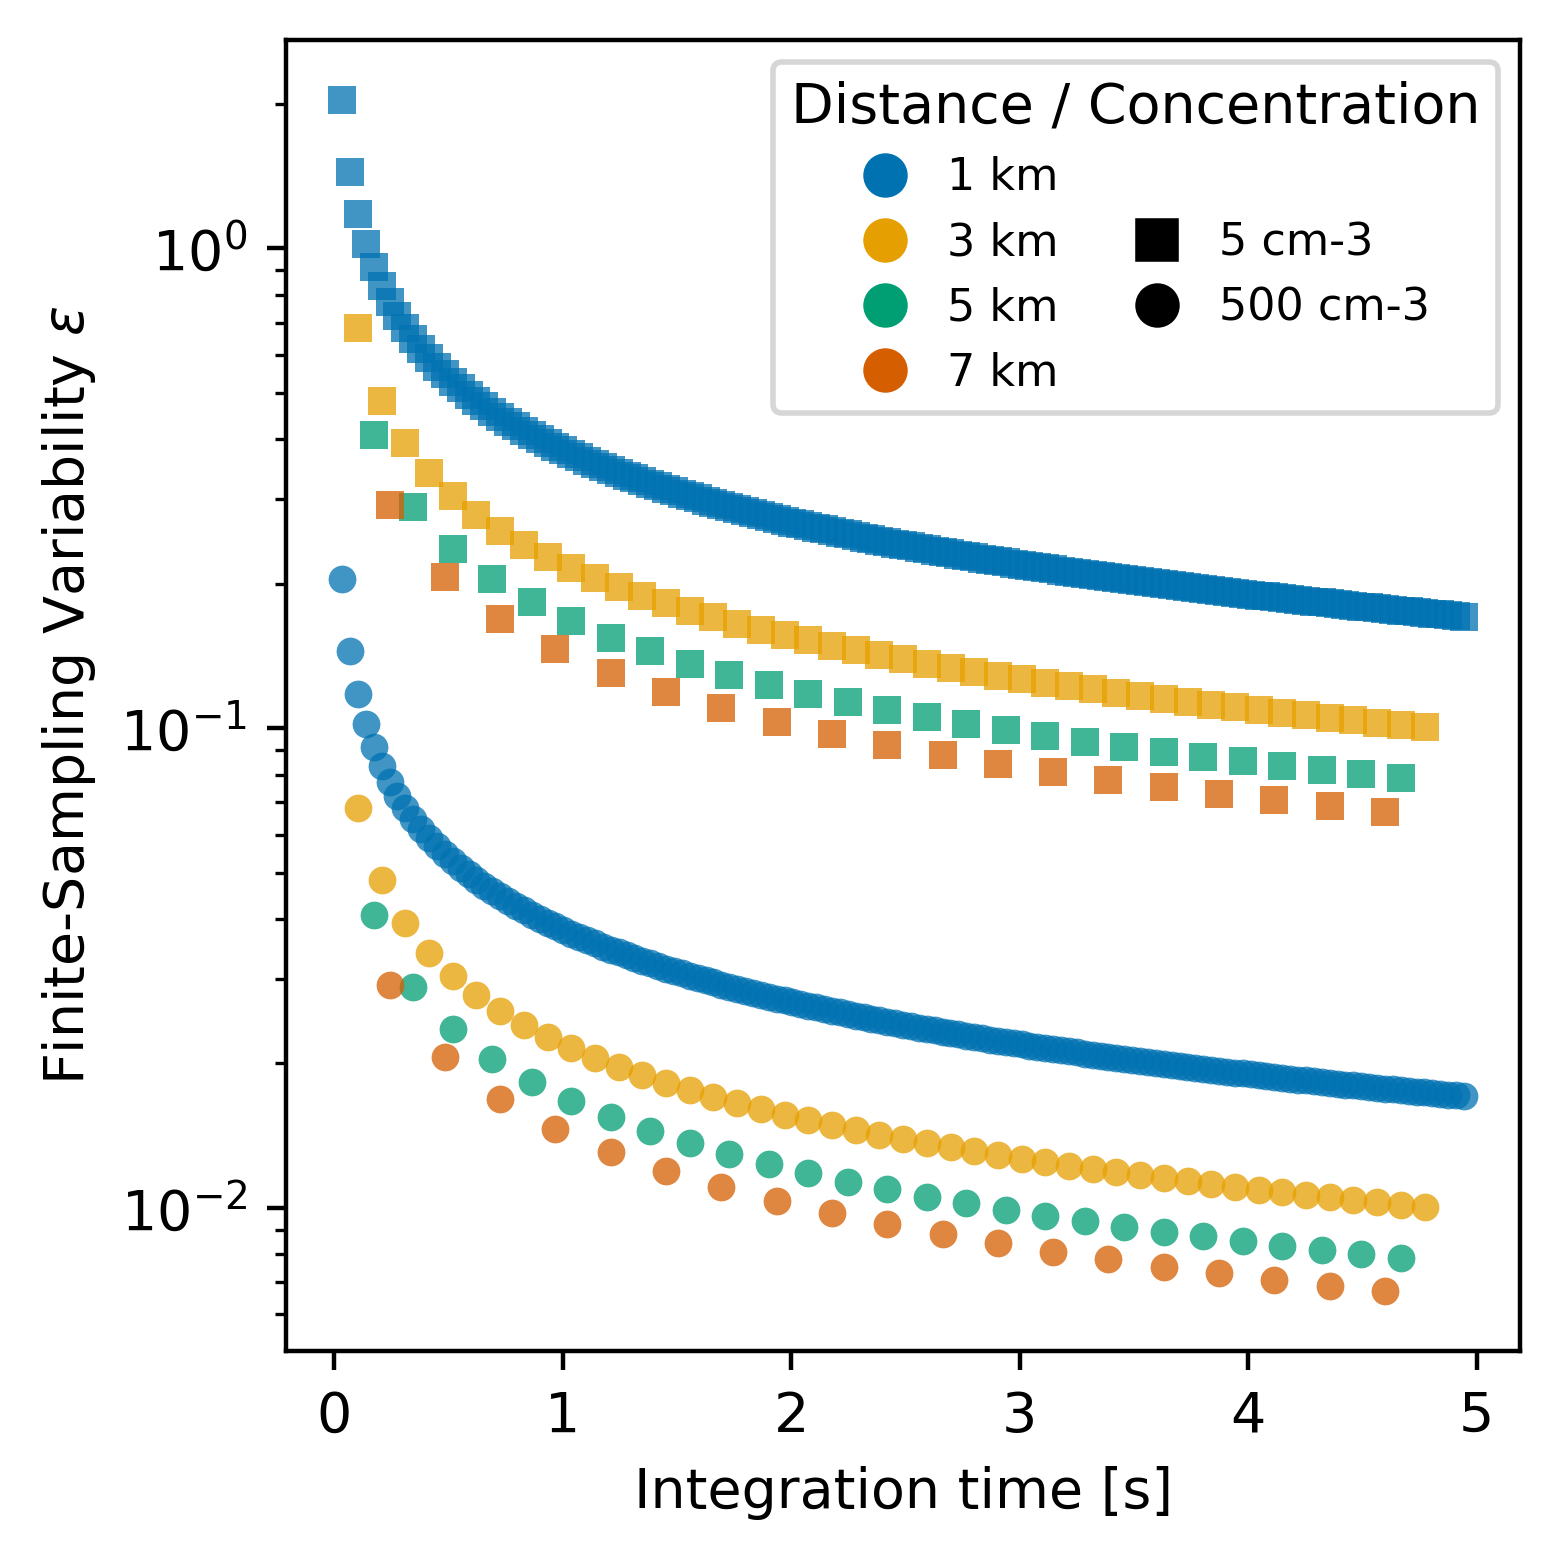

In [128]:
from matplotlib.lines import Line2D

fig = plt.figure(dpi=400, figsize=(4,4))
ax = fig.add_subplot(111)

# colors = []
colors = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # bluish green
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
]

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

# First concentration
for i in range(len(deltas)):
    line, = ax.plot(
        ts[i],
        deltas[i],
        'o',
        alpha=0.75,
        markersize=5,
        markeredgewidth=0
    )

    # colors.append(line.get_color())

# Second concentration
for i in range(len(deltas_new)):
    ax.plot(
        ts_new[i],
        deltas_new[i],
        's',
        color=colors[i],
        alpha=0.75,
        markersize=5,
        markeredgewidth=0
    )

# --- distance handles (colors) ---
distance_handles = [
    Line2D([0], [0],
           marker='o',
           color=c,
           linestyle='None',
           markersize=7,
           label=f'{z/1e3:.0f} km')
    for c, z in zip(colors, zs)
]

# --- concentration handles (shapes) ---
conc_handles = [
    Line2D([0], [0],
           marker='s',
           color='k',
           linestyle='None',
           markersize=7,
           label='{:.0f} cm-3'.format(N_tot_2)),

    Line2D([0], [0],
           marker='o',
           color='k',
           linestyle='None',
           markersize=7,
           label='{:.0f} cm-3'.format(N_tot_1))
]

# spacer
blank = Line2D([], [], linestyle='None', label='')

handles = distance_handles + [blank] + conc_handles

ax.legend(
    handles=handles,
    ncol=2,
    title='Distance / Concentration',
    columnspacing=1.2,
    handletextpad=0.4,
    loc='upper right',
    fontsize=8
)

ax.set_xlabel('Integration time [s]')
ax.set_ylabel('Finite-Sampling Variability $\epsilon$')
# fig.suptitle('Relative Uncertainty')
# ax.set_title('Advection rate: {:.2f} m/s'.format(params['v']), fontsize=8)
ax.set_yscale('log')
# plt.legend(
#     title='Distance [km], Concentration [cm-3]', 
#     ncol=2,
#     columnspacing=1.0,
#     handletextpad=0.3
# )
plt.tight_layout()
# plt.savefig(dpi=400, fname=r'C:\Users\gkirc\OneDrive - UCB-O365\ARSENL\Manuscripts\Rain Lidar Paper\version 2\figures\fig03a.png')
fig.savefig(fname=r'C:\Users\gkirc\OneDrive - UCB-O365\ARSENL\Manuscripts\Rain Lidar Paper\version 2\figures\fig03a.pdf', bbox_inches="tight")
plt.show()

# Change size distribution relative width

In [121]:
# Iterate through different ranges
params = params_original.copy()

# zs_start = 1e3
# zs_end = 7e3
# z_step = 2e3
# zs = np.arange(zs_start, zs_end + z_step, z_step)
alphas = np.array([5, 10, 15, 20])

deltas = []
ts = []
for i in range(len(zs)):
    # params['z_target'] = zs[i]
    params['alpha'] = alphas[i]
    
    du = DiscreteUncertainty(params)
    w_target = du.calc_beam_params()
    E_IA, E_IA2 = du.calc_transverse_I(w_target)
    E_Iz, E_Iz2, width = du.calc_z_I()
    CV_I = du.calc_uncertainty_I(E_IA2, E_Iz2, E_IA, E_Iz)
    CV_S, N_tot, n_dist, D = du.calc_uncertainty_S()
    CV_IS = du.calc_uncertainty_IS(CV_I, CV_S)
    delta, t = du.sample_volume(w_target, width, CV_IS, N_tot)

    deltas.append(delta)
    ts.append(t)

N_tot_1 = N_tot
# print(deltas)

# deltas = np.array(deltas)


Full-width waist: 0.35 m
Full angle divergence: 172.86 urad

2D Calculations
Peak irradiance: 0.186 W/m
Expected irradiance: 0.147 W/m^2
Coefficient of variation: 0.144

Depth Dimension (pulse)
Pulse width: 0.10 m
Effective width: 0.30 m
Variance of I_z: 0.08
Coefficient of Variation: 0.44

Variance of I: 0.00
Coefficient of Variation: 0.47
Total number concentration: 5.00e+02 cm-3
Expected differential-backscatter cross section: 5.89e-18 m^2 sr-1
Variance in differential-backscatter cross section: 7.83e-30 (m^2 sr-1)^2
Coefficient of variation for differential-backscatter cross section: 474.96
Coefficient of Variation I: 0.47
Coefficient of Variation S: 474.96
Effective Coefficient of Variation: 524.81

Sample volume:

Distance: 2.00 km
Number concentration: 500 m-3
Area: 0.09 m^2
Transverse diameter: 0.35 m
Depth: 0.30 m
Volume: 0.03 m^3
Expected number of particles: 13981738.78


Full-width waist: 0.35 m
Full angle divergence: 172.86 urad

2D Calculations
Peak irradiance: 0.186 W/m

C:\Users\gkirc\AppData\Local\Temp\ipykernel_9880\3005575888.py:180: RuntimeWarning: divide by zero encountered in divide
  delta = 1/np.sqrt(N) * CV_IS


In [122]:
# Iterate through different ranges
params = params_original.copy()
params['N_0'] = 5  # [cm-3]

deltas_new = []
ts_new = []
for i in range(len(zs)):
    # params['z_target'] = zs[i]
    params['alpha'] = alphas[i]
    
    du = DiscreteUncertainty(params)
    w_target = du.calc_beam_params()
    E_IA, E_IA2 = du.calc_transverse_I(w_target)
    E_Iz, E_Iz2, width = du.calc_z_I()
    CV_I = du.calc_uncertainty_I(E_IA2, E_Iz2, E_IA, E_Iz)
    CV_S, N_tot, n_dist, D = du.calc_uncertainty_S()
    CV_IS = du.calc_uncertainty_IS(CV_I, CV_S)
    delta, t = du.sample_volume(w_target, width, CV_IS, N_tot)

    deltas_new.append(delta)
    ts_new.append(t)

N_tot_2 = N_tot


Full-width waist: 0.35 m
Full angle divergence: 172.86 urad

2D Calculations
Peak irradiance: 0.186 W/m
Expected irradiance: 0.147 W/m^2
Coefficient of variation: 0.144

Depth Dimension (pulse)
Pulse width: 0.10 m
Effective width: 0.30 m
Variance of I_z: 0.08
Coefficient of Variation: 0.44

Variance of I: 0.00
Coefficient of Variation: 0.47


C:\Users\gkirc\AppData\Local\Temp\ipykernel_9880\3005575888.py:180: RuntimeWarning: divide by zero encountered in divide
  delta = 1/np.sqrt(N) * CV_IS


Total number concentration: 5.00e+00 cm-3
Expected differential-backscatter cross section: 5.89e-18 m^2 sr-1
Variance in differential-backscatter cross section: 7.83e-30 (m^2 sr-1)^2
Coefficient of variation for differential-backscatter cross section: 474.96
Coefficient of Variation I: 0.47
Coefficient of Variation S: 474.96
Effective Coefficient of Variation: 524.81

Sample volume:

Distance: 2.00 km
Number concentration: 5 m-3
Area: 0.09 m^2
Transverse diameter: 0.35 m
Depth: 0.30 m
Volume: 0.03 m^3
Expected number of particles: 139817.39


Full-width waist: 0.35 m
Full angle divergence: 172.86 urad

2D Calculations
Peak irradiance: 0.186 W/m
Expected irradiance: 0.147 W/m^2
Coefficient of variation: 0.144

Depth Dimension (pulse)
Pulse width: 0.10 m
Effective width: 0.30 m
Variance of I_z: 0.08
Coefficient of Variation: 0.44

Variance of I: 0.00
Coefficient of Variation: 0.47
Total number concentration: 5.00e+00 cm-3
Expected differential-backscatter cross section: 2.16e-17 m^2 sr-1

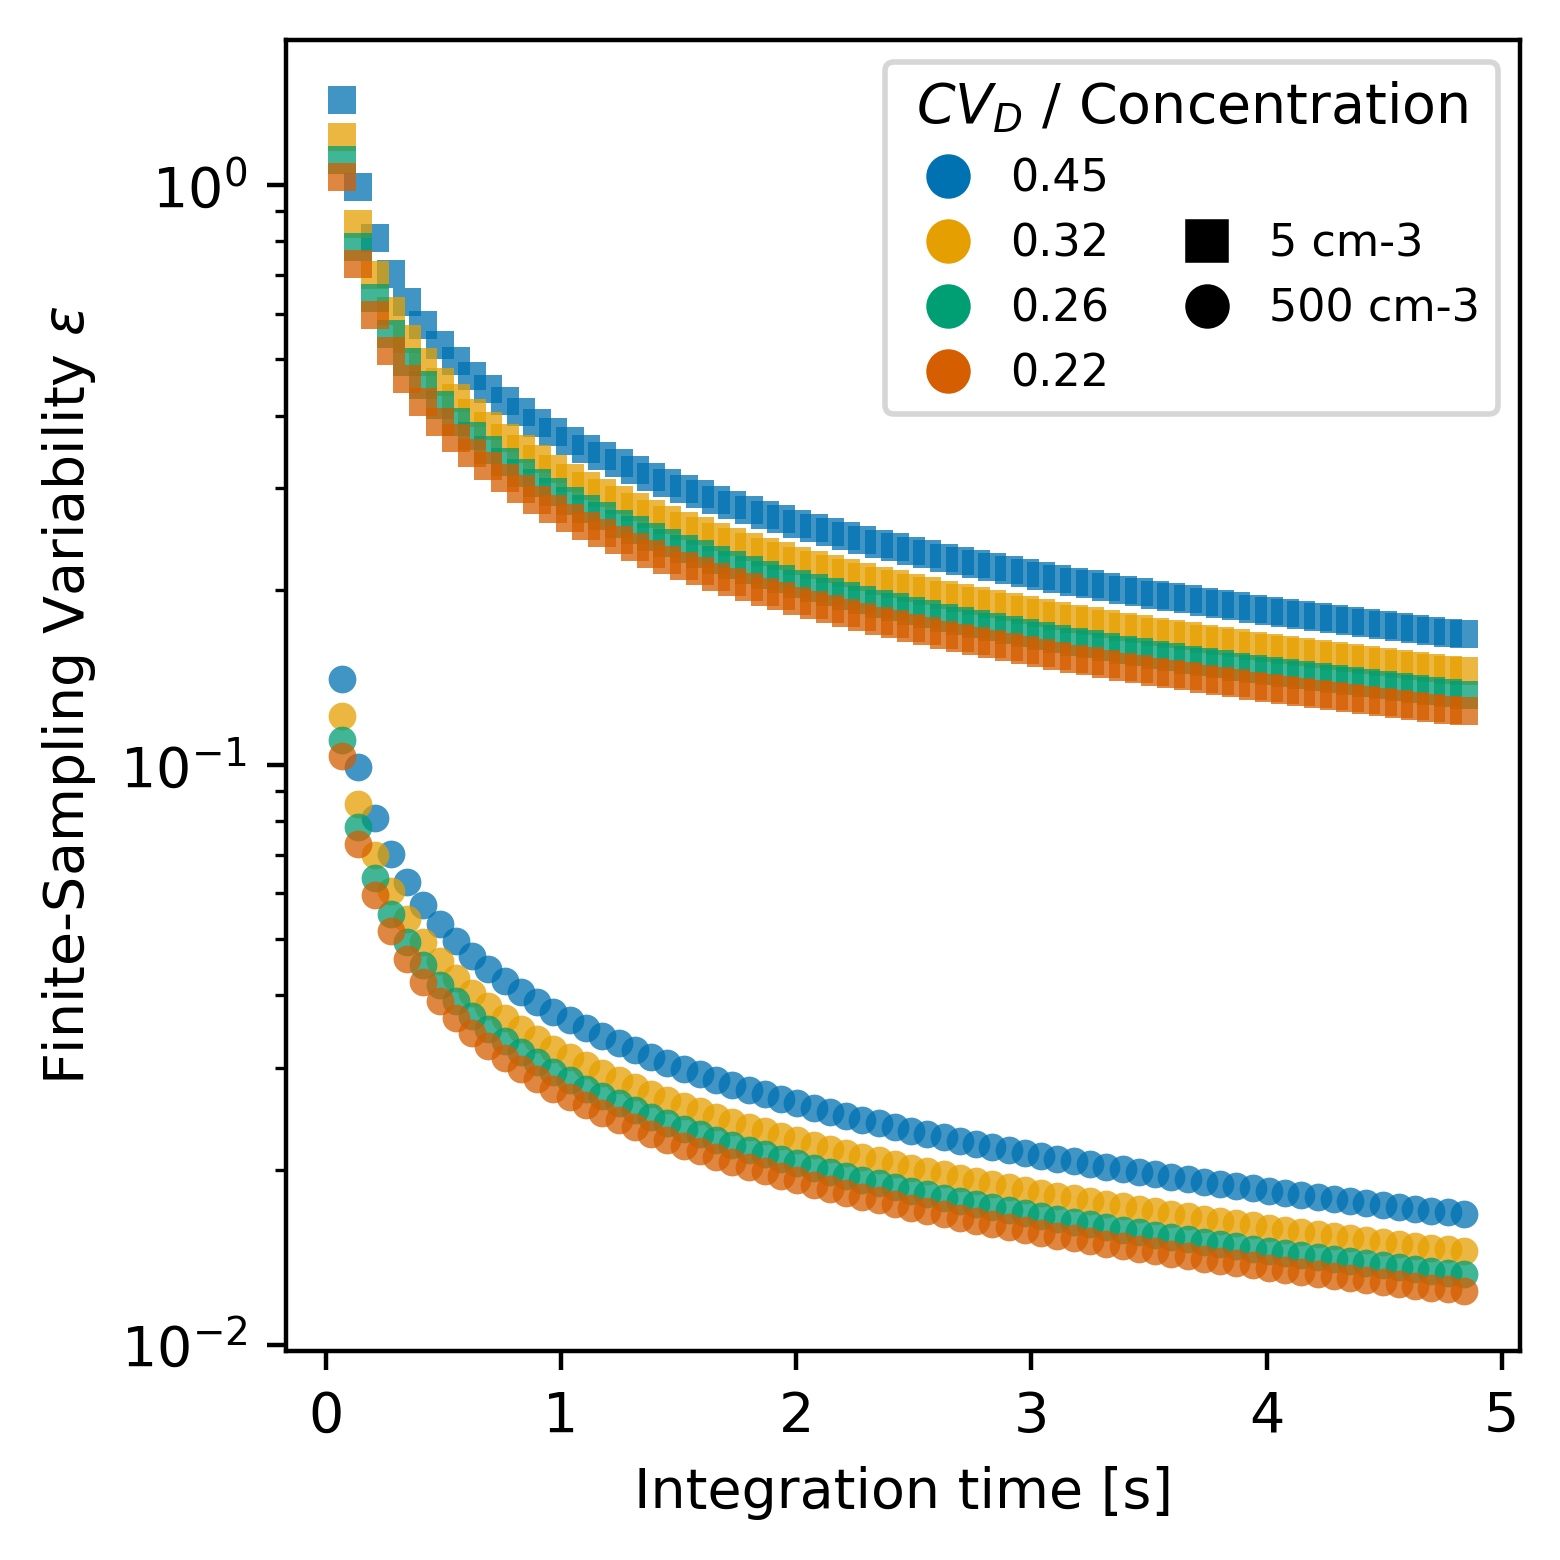

In [124]:
from matplotlib.lines import Line2D

fig = plt.figure(dpi=400, figsize=(4,4))
ax = fig.add_subplot(111)

# colors = []
colors = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # bluish green
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
]

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

# First concentration
for i in range(len(deltas)):
    line, = ax.plot(
        ts[i],
        deltas[i],
        'o',
        alpha=0.75,
        markersize=5,
        markeredgewidth=0
    )

    # colors.append(line.get_color())

# Second concentration
for i in range(len(deltas_new)):
    ax.plot(
        ts_new[i],
        deltas_new[i],
        's',
        color=colors[i],
        alpha=0.75,
        markersize=5,
        markeredgewidth=0
    )

# --- distance handles (colors) ---
distance_handles = [
    Line2D([0], [0],
           marker='o',
           color=c,
           linestyle='None',
           markersize=7,
           label=f'{1/np.sqrt(a):.2f}')
    for c, a in zip(colors, alphas)
]

# --- concentration handles (shapes) ---
conc_handles = [
    Line2D([0], [0],
           marker='s',
           color='k',
           linestyle='None',
           markersize=7,
           label='{:.0f} cm-3'.format(N_tot_2)),

    Line2D([0], [0],
           marker='o',
           color='k',
           linestyle='None',
           markersize=7,
           label='{:.0f} cm-3'.format(N_tot_1))
]

# spacer
blank = Line2D([], [], linestyle='None', label='')

handles = distance_handles + [blank] + conc_handles

ax.legend(
    handles=handles,
    ncol=2,
    title='$CV_D$ / Concentration',
    columnspacing=1.2,
    handletextpad=0.4,
    loc='upper right',
    fontsize=8
)

ax.set_xlabel('Integration time [s]')
ax.set_ylabel('Finite-Sampling Variability $\epsilon$')
# fig.suptitle('Relative Uncertainty')
# ax.set_title('Advection rate: {:.2f} m/s'.format(params['v']), fontsize=8)
ax.set_yscale('log')
# plt.legend(
#     title='Distance [km], Concentration [cm-3]', 
#     ncol=2,
#     columnspacing=1.0,
#     handletextpad=0.3
# )
plt.tight_layout()
fig.savefig(fname=r'C:\Users\gkirc\OneDrive - UCB-O365\ARSENL\Manuscripts\Rain Lidar Paper\version 2\figures\fig03b.pdf', bbox_inches="tight")
# plt.savefig(dpi=400, fname=r'C:\Users\gkirc\OneDrive - UCB-O365\ARSENL\Manuscripts\Rain Lidar Paper\version 2\figures\fig03b.png')
plt.show()

In [ ]:
# Iterate through number concentrations
params = params_original.copy()

N_0_start = -4  # [exp(cm-3)]
N_0_end = 4  # [exp(cm-3)]
N_0_tot = 9 
N_0s = np.logspace(N_0_start, N_0_end, N_0_tot)  # [cm-3] number concentrations

deltas = []
ts = []
for i in range(len(N_0s)):
    params['N_0'] = N_0s[i]
    
    du = DiscreteUncertainty(params)
    w_target = du.calc_beam_params()
    E_IA, E_IA2 = du.calc_transverse_I(w_target)
    E_Iz, E_Iz2, width = du.calc_z_I()
    CV_I = du.calc_uncertainty_I(E_IA2, E_Iz2, E_IA, E_Iz)
    CV_S, N_tot, n_dist, D = du.calc_uncertainty_S()
    CV_IS = du.calc_uncertainty_IS(CV_I, CV_S)
    delta, t = du.sample_volume(w_target, width, CV_IS, N_tot)

    deltas.append(delta)
    ts.append(t)

# deltas = np.array(deltas)

In [ ]:
fig = plt.figure(dpi=300)
ax = fig.add_subplot(111)
for i in range(len(deltas)):
    ax.plot(ts[i], deltas[i], 'o', alpha=0.75, markersize=3, markeredgewidth=0, label='{:.0e}'.format(N_0s[i]))
ax.set_xlabel('Integration time [s]')
ax.set_ylabel('$\delta P/P$')
fig.suptitle('Relative Uncertainty')
ax.set_title('Advection rate: {:.2f} m/s\nDistance: {:.2f} km'.format(params['v'], params['z_target']/1e3), fontsize=10)
ax.set_yscale('log')
plt.legend(title='Number Concentration [cm-3]')
plt.tight_layout()
plt.show()

In [ ]:
vel = np.array([6.7, 5.3, 6.8, 5.5, 7.9, 5.4])

counts, bins = np.histogram(vel, bins=4)

fig = plt.figure(dpi=400, figsize=(0.5,2.5))
ax = fig.add_subplot(111)
ax.hist(bins[:-1], bins, weights=counts)
ax.set_xlabel('V [m/s]')
plt.show()